In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('Uber Demand.csv', encoding='ISO-8859-1')
df

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,Hour,Timeslot,Cancelled Flag,No cars availabe
0,619,Airport,1,Trip Completed,11/7/2016 11:51,11/7/2016 13:00,11,11:00-12:00,0,0
1,867,Airport,1,Trip Completed,11/7/2016 17:57,11/7/2016 18:47,17,17:00-18:00,0,0
2,1807,City,1,Trip Completed,12/7/2016 9:17,12/7/2016 9:58,9,09:00-10:00,0,0
3,2532,Airport,1,Trip Completed,12/7/2016 21:08,12/7/2016 22:03,21,21:00-22:00,0,0
4,3112,City,1,Trip Completed,13-07-2016 08:33:16,13-07-2016 09:25:47,8,08:00-09:00,0,0
...,...,...,...,...,...,...,...,...,...,...
6740,6745,City,0,No Cars Available,15-07-2016 23:49:03,0,#VALUE!,#VALUE!,0,1
6741,6752,Airport,0,No Cars Available,15-07-2016 23:50:05,0,#VALUE!,#VALUE!,0,1
6742,6751,City,0,No Cars Available,15-07-2016 23:52:06,0,#VALUE!,#VALUE!,0,1
6743,6754,City,0,No Cars Available,15-07-2016 23:54:39,0,#VALUE!,#VALUE!,0,1


In [5]:
df.columns = df.columns.str.strip()

In [6]:
#Quick Data Overview
df.head()


,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,Hour,Timeslot,Cancelled Flag,No cars availabe
0,619,Airport,1,Trip Completed,11/7/2016 11:51,11/7/2016 13:00,11,11:00-12:00,0,0
1,867,Airport,1,Trip Completed,11/7/2016 17:57,11/7/2016 18:47,17,17:00-18:00,0,0
2,1807,City,1,Trip Completed,12/7/2016 9:17,12/7/2016 9:58,9,09:00-10:00,0,0
3,2532,Airport,1,Trip Completed,12/7/2016 21:08,12/7/2016 22:03,21,21:00-22:00,0,0
4,3112,City,1,Trip Completed,13-07-2016 08:33:16,13-07-2016 09:25:47,8,08:00-09:00,0,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Request id         6745 non-null   int64 
 1   Pickup point       6745 non-null   object
 2   Driver id          6745 non-null   int64 
 3   Status             6745 non-null   object
 4   Request timestamp  6745 non-null   object
 5   Drop timestamp     6745 non-null   object
 6   Hour               6745 non-null   object
 7   Timeslot           6745 non-null   object
 8   Cancelled Flag     6745 non-null   int64 
 9   No cars availabe   6745 non-null   int64 
dtypes: int64(4), object(6)
memory usage: 527.1+ KB


In [8]:
df.describe()

,Request id,Driver id,Cancelled Flag,No cars availabe
count,6745.000000,6745.000000,6745.000000,6745.000000
mean,3384.644922,90.764715,0.187398,0.392884
std,1955.099667,99.132418,0.390260,0.488428
min,1.000000,0.000000,0.000000,0.000000
25%,1691.000000,0.000000,0.000000,0.000000
50%,3387.000000,53.000000,0.000000,0.000000
75%,5080.000000,177.000000,0.000000,1.000000
max,6766.000000,300.000000,1.000000,1.000000


       Timeslot  Total Rides
0   00:00-01:00           32
1   01:00-02:00           28
2   02:00-03:00           30
3   03:00-04:00           31
4   04:00-05:00           83
5   05:00-06:00          172
6   06:00-07:00          172
7   07:00-08:00          150
8   08:00-09:00          161
9   09:00-10:00          190
10  10:00-11:00           92
11  11:00-12:00           81
12  12:00-13:00           82
13  13:00-14:00           59
14  14:00-15:00           59
15  15:00-16:00           67
16  16:00-17:00           71
17  17:00-18:00          170
18  18:00-19:00          205
19  19:00-20:00          193
20  20:00-21:00          195
21  21:00-22:00          187
22  22:00-23:00          108
23  23:00-24:00           67


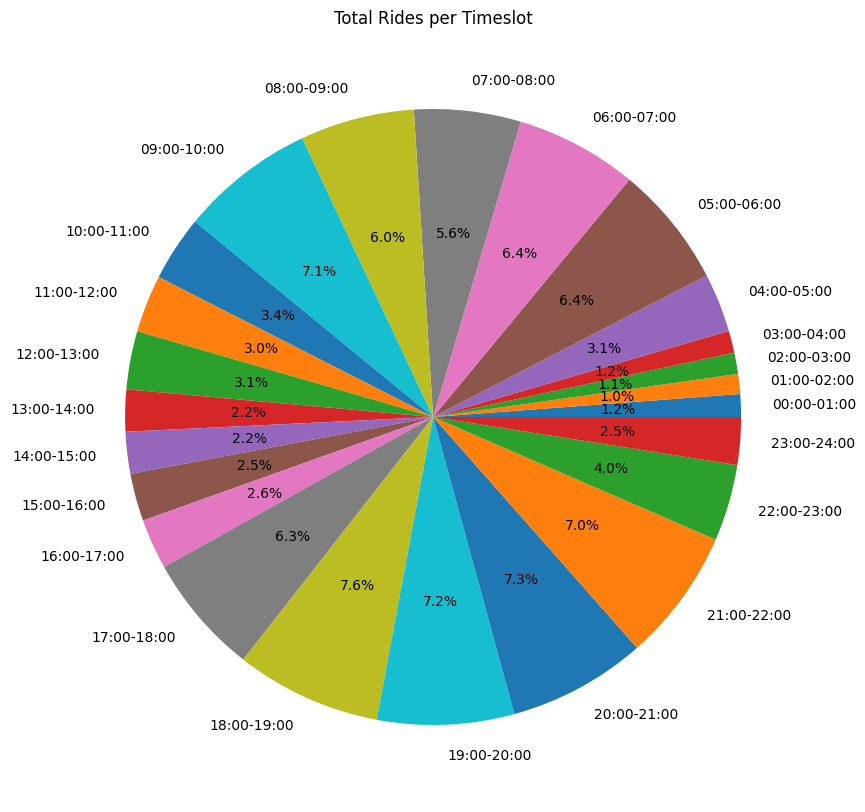

In [9]:
# Remove rows with '#VALUE!' in Timeslot
df = df[df['Timeslot'] != '#VALUE!']

# Now do the grouping
timeslot_counts = df.groupby('Timeslot')['Request id'].count().reset_index()
timeslot_counts.rename(columns={'Request id':'Total Rides'}, inplace=True)

print(timeslot_counts)

# Plot pie chart
plt.figure(figsize=(15,10))
plt.pie(timeslot_counts['Total Rides'], labels=timeslot_counts['Timeslot'], autopct='%1.1f%%')
plt.title('Total Rides per Timeslot')
plt.show()


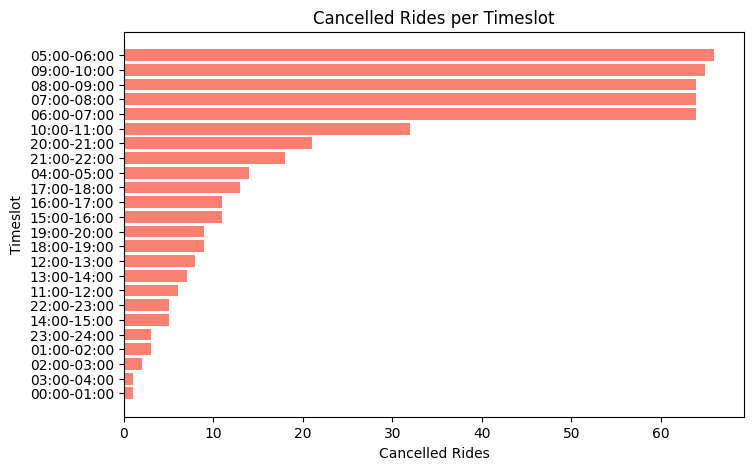

In [10]:
df = df[df['Timeslot'] != '#VALUE!']
# Cancelled Rides per Timeslot - Horizontal Bar
df_cancelled = df.groupby('Timeslot')['Cancelled Flag'].sum().sort_values().reset_index()
plt.figure(figsize=(8,5))
plt.barh(df_cancelled['Timeslot'], df_cancelled['Cancelled Flag'], color='salmon')
plt.title('Cancelled Rides per Timeslot')
plt.xlabel('Cancelled Rides')
plt.ylabel('Timeslot')
plt.show()

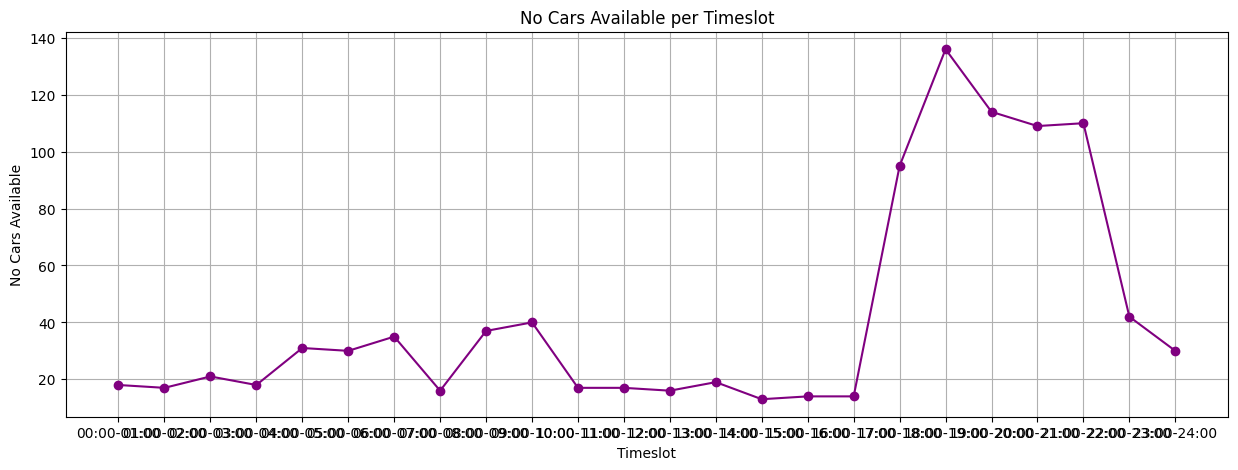

In [11]:
df = df[df['Timeslot'] != '#VALUE!']

# No Cars Available per Timeslot - Line Plot
nocars_counts = df.groupby('Timeslot')['No cars availabe'].sum().reset_index()
plt.figure(figsize=(15,5))
plt.plot(nocars_counts['Timeslot'], nocars_counts['No cars availabe'], marker='o', linestyle='-', color='purple')
plt.title('No Cars Available per Timeslot')
plt.xlabel('Timeslot')
plt.ylabel('No Cars Available')
plt.grid(True)
plt.show()


In [12]:
df = df[df['Timeslot'] != '#VALUE!']

#Cancellation % and Supply-Demand Gap per Timeslot - Seaborn Scatter
df_eda = df.groupby('Timeslot').agg({'Request id':'count','Cancelled Flag':'sum','No cars availabe':'sum'}).reset_index()
df_eda['Cancellation %'] = (df_eda['Cancelled Flag']/df_eda['Request id'])*100
df_eda['Supply-Demand Gap'] = df_eda['No cars availabe']
print(df_eda)

       Timeslot  Request id  Cancelled Flag  No cars availabe  Cancellation %  \
0   00:00-01:00          32               1                18        3.125000   
1   01:00-02:00          28               3                17       10.714286   
2   02:00-03:00          30               2                21        6.666667   
3   03:00-04:00          31               1                18        3.225806   
4   04:00-05:00          83              14                31       16.867470   
5   05:00-06:00         172              66                30       38.372093   
6   06:00-07:00         172              64                35       37.209302   
7   07:00-08:00         150              64                16       42.666667   
8   08:00-09:00         161              64                37       39.751553   
9   09:00-10:00         190              65                40       34.210526   
10  10:00-11:00          92              32                17       34.782609   
11  11:00-12:00          81 

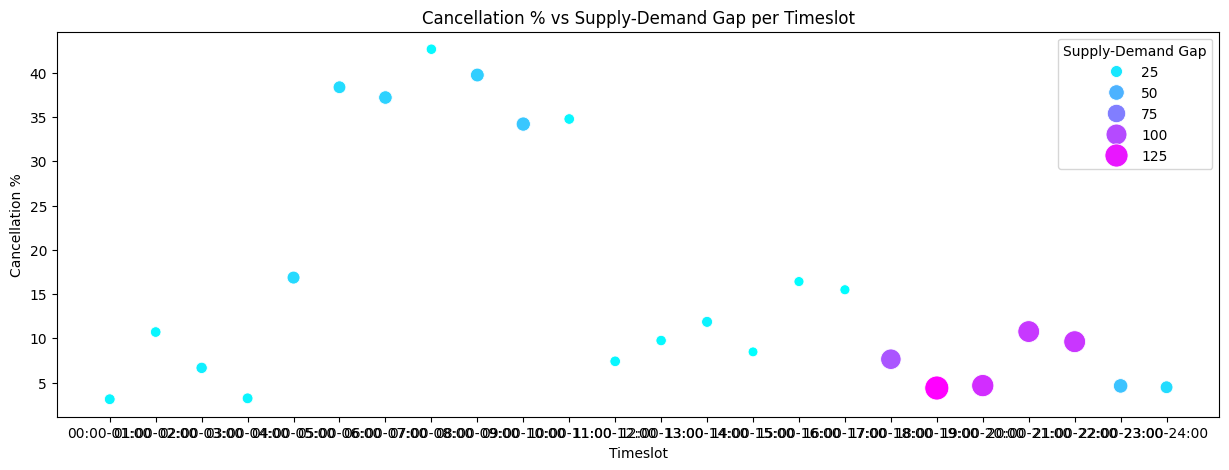

In [13]:
df = df[df['Timeslot'] != '#VALUE!']

plt.figure(figsize=(15,5))
sns.scatterplot(data=df_eda, x='Timeslot', y='Cancellation %', size='Supply-Demand Gap', hue='Supply-Demand Gap', palette='cool', sizes=(50,300))
plt.title('Cancellation % vs Supply-Demand Gap per Timeslot')
plt.xlabel('Timeslot')
plt.ylabel('Cancellation %')
plt.show()